<a href="https://colab.research.google.com/github/Lucaaa31/Anomaly-Segmentation/blob/master/EoMT_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 4: EoMT Evaluation on Cityscapes val

Compare the two EoMT checkpoints on Cityscapes val:

* **EoMT-CS** (Cityscapes-trained, semantic, 19 classes): direct predictions
* **EoMT-COCO** (COCO-trained, panoptic, 133 classes): panoptic predictions + semantic remapping to Cityscapes

Output: 1) qualitative visualizations on sample images, 2) quantitative mIoU for both.


## 1. Mount Drive and environment setup

In [16]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation
!git pull origin master 2>/dev/null || echo "(git pull skipped)"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation
Updating 2c01155..c9a8d86
(git pull skipped)


## 2. Install dependencies

We install directly in Colab's Python (no conda). Only the dependencies
needed for the vendored EoMT inference, no `jsonargparse`,
`gitignore_parser` or `wandb login` (those are only needed for the training).

In [17]:
!pip install -q lightning timm transformers wandb pyyaml torchmetrics fvcore scipy pycocotools

## 3. Imports and path

In [18]:
import sys, importlib, yaml
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation")
EOMT_DIR  = REPO_ROOT / "eomt"
DATA_PATH = REPO_ROOT / "dataset" / "Validation_Dataset" / "Cityscapes"
sys.path.insert(0, str(EOMT_DIR))

assert torch.cuda.is_available(), \
    "Enable GPU runtime: Runtime → Change runtime type → T4 GPU"
device = torch.device("cuda")
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.10.0+cu128


## 4. Helper for building models

Replicates the pattern of `eomt/inference.ipynb`: it reads the YAML config, instantiates encoder + network + Lightning module via `importlib`, and loads the `.bin` weights. **It does not call `data.setup()`** : from the data module, we only need `num_classes`/`img_size`/`stuff_classes` as metadata, as we do not want to open the COCO zip files.

In [19]:
def build_model(config_path, ckpt_path, data_path, device):
    """Costruisce un EoMT model da config YAML + checkpoint .bin."""
    with open(config_path) as f:
        cfg = yaml.safe_load(f)

    # data module (solo metadata, no setup)
    dm_mod, dm_cls = cfg["data"]["class_path"].rsplit(".", 1)
    DataCls = getattr(importlib.import_module(dm_mod), dm_cls)
    data = DataCls(
        path=str(data_path), batch_size=1, num_workers=0,
        check_empty_targets=False, **cfg["data"].get("init_args", {}),
    )

    # encoder (DINOv2)
    enc_cfg = cfg["model"]["init_args"]["network"]["init_args"]["encoder"]
    em, ec = enc_cfg["class_path"].rsplit(".", 1)
    EncCls = getattr(importlib.import_module(em), ec)
    encoder = EncCls(img_size=data.img_size, **enc_cfg.get("init_args", {}))

    # network (EoMT, masked_attn_enabled=False come in inference.ipynb)
    net_cfg = cfg["model"]["init_args"]["network"]
    nm, nc = net_cfg["class_path"].rsplit(".", 1)
    NetCls = getattr(importlib.import_module(nm), nc)
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}
    network = NetCls(masked_attn_enabled=False, num_classes=data.num_classes,
                     encoder=encoder, **net_kwargs)

    # lightning module
    lm, lc = cfg["model"]["class_path"].rsplit(".", 1)
    LitCls = getattr(importlib.import_module(lm), lc)
    model_kwargs = {k: v for k, v in cfg["model"]["init_args"].items() if k != "network"}
    if "stuff_classes" in cfg["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = cfg["data"]["init_args"]["stuff_classes"]
    model = LitCls(img_size=data.img_size, num_classes=data.num_classes,
                   network=network, **model_kwargs).eval().to(device)

    # weights
    sd = torch.load(str(ckpt_path), map_location=device, weights_only=True)
    if "state_dict" in sd:
        sd = sd["state_dict"]
    sd = {k.replace("._orig_mod", ""): v for k, v in sd.items()}
    inc = model.load_state_dict(sd, strict=False)
    print(f"  loaded {Path(ckpt_path).name}: "
          f"missing={len(inc.missing_keys)} unexpected={len(inc.unexpected_keys)}")
    return model, data

## 5. Load the two checkpoints

In [20]:
cs_config = EOMT_DIR / "configs" / "dinov2" / "cityscapes" / "semantic" / "eomt_base_640.yaml"
cs_ckpt   = REPO_ROOT / "models" / "eomt_cityscapes.bin"
print("Building Cityscapes-trained EoMT...")
cs_model, cs_meta = build_model(cs_config, cs_ckpt, DATA_PATH, device)
print(f"  num_classes={cs_meta.num_classes}  img_size={cs_meta.img_size}")

Building Cityscapes-trained EoMT...
  loaded eomt_cityscapes.bin: missing=0 unexpected=0
  num_classes=19  img_size=(1024, 1024)


In [21]:
coco_config = EOMT_DIR / "configs" / "dinov2" / "coco" / "panoptic" / "eomt_base_640_2x.yaml"
coco_ckpt   = REPO_ROOT / "models" / "eomt_coco.bin"
print("Building COCO-trained EoMT...")
coco_model, coco_meta = build_model(coco_config, coco_ckpt, DATA_PATH, device)
print(f"  num_classes={coco_meta.num_classes}  img_size={coco_meta.img_size}")

Building COCO-trained EoMT...


  loaded eomt_coco.bin: missing=0 unexpected=0
  num_classes=133  img_size=(640, 640)


## 6. Load the Cityscapes val dataset

Read directly from the two zips: `leftImg8bit_trainvaltest.zip` and `gtFine_trainvaltest.zip`. Change `img_idx` to explore different images.

In [22]:
from datasets.cityscapes_semantic import CityscapesSemantic

print("Loading Cityscapes val dataset (from zips)...")
cs_data = CityscapesSemantic(
    path=str(DATA_PATH), batch_size=1, num_workers=0, check_empty_targets=False,
).setup()
val_dataset = cs_data.val_dataloader().dataset
print(f"  {len(val_dataset)} validation images")

img_idx = 10   # <-- switch for different images
img, target_dict = val_dataset[img_idx]
print(f"image {img_idx}: shape={tuple(img.shape)}  "
      f"GT classes={sorted(target_dict['labels'].tolist())}")

Loading Cityscapes val dataset (from zips)...
  500 validation images
image 10: shape=(3, 1024, 2048)  GT classes=[0, 1, 2, 4, 5, 6, 8, 9, 10, 13]


## 7. Inference Helper (semantic + panoptic)

In [23]:
@torch.no_grad()
def infer_semantic_logits(model, img):
    """Logits per-pixel [num_classes, H, W]. Funziona sia per modelli semantic-trained
    sia panoptic-trained: il head di mask-classification supporta entrambi i casi."""
    imgs = [img.to(device)]
    img_sizes = [img.shape[-2:]]
    crops, origins = model.window_imgs_semantic(imgs)
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        m_logits, c_logits = model(crops)
    m_logits = F.interpolate(m_logits[-1], model.img_size, mode="bilinear")
    crop_logits = model.to_per_pixel_logits_semantic(m_logits, c_logits[-1])
    return model.revert_window_logits_semantic(crop_logits, origins, img_sizes)[0]


@torch.no_grad()
def infer_panoptic(model, img):
    """Predizione panoptica: ritorna (sem[H,W], inst[H,W]) come array numpy."""
    imgs = [img.to(device)]
    img_sizes = [img.shape[-2:]]
    transformed = model.resize_and_pad_imgs_instance_panoptic(imgs)
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        m_logits, c_logits = model(transformed)
    m_logits = F.interpolate(m_logits[-1], model.img_size, mode="bilinear")
    m_logits = model.revert_resize_and_pad_logits_instance_panoptic(m_logits, img_sizes)
    preds = model.to_per_pixel_preds_panoptic(
        m_logits, c_logits[-1], model.stuff_classes,
        model.mask_thresh, model.overlap_thresh,
    )[0].cpu().numpy()
    return preds[..., 0], preds[..., 1]

## 8. Semantic prediction of the CS-trained model

Three panels: image, prediction, ground truth. The 19 Cityscapes classes are shown with the `tab20` palette.

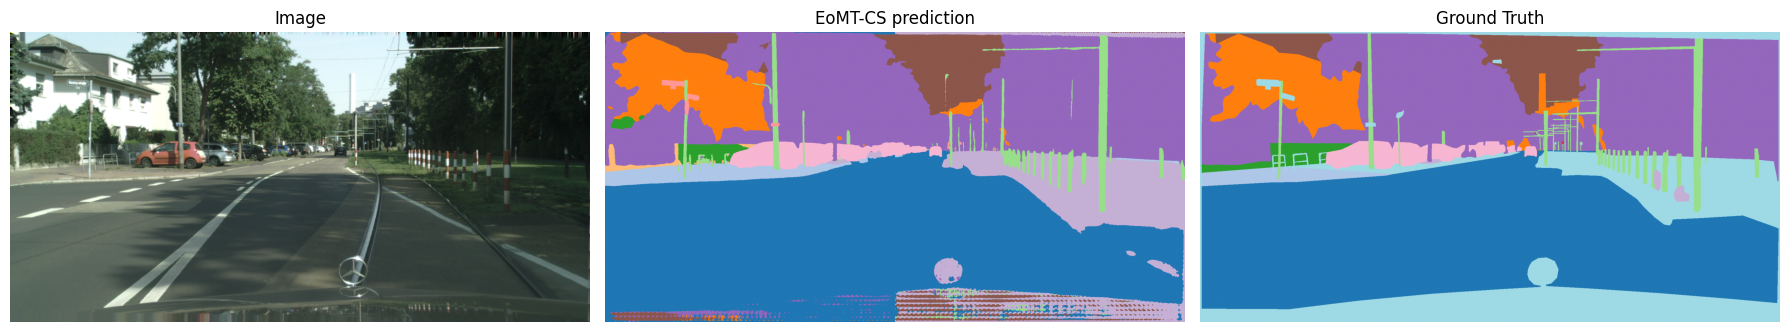

In [24]:
logits = infer_semantic_logits(cs_model, img)
pred_cs = logits.argmax(0).cpu().numpy()
target = cs_model.to_per_pixel_targets_semantic([target_dict], 255)[0].cpu().numpy()
target_vis = np.where(target == 255, 19, target)  # ignore -> ultima fascia

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img.permute(1, 2, 0).cpu().numpy());                  axes[0].set_title("Image")
axes[1].imshow(pred_cs,    cmap="tab20", vmin=0, vmax=19);           axes[1].set_title("EoMT-CS prediction")
axes[2].imshow(target_vis, cmap="tab20", vmin=0, vmax=19);           axes[2].set_title("Ground Truth")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 9. Panoptic prediction of the COCO-trained model

Panoptic output: each pixel has both a semantic class (out of the 133 from COCO) and an instance id. We color with a random hue per class + black borders between different segments (same style as `eomt/inference.ipynb`).

unique semantic classes in panoptic prediction: [2, 91, 100, 116, 117, 119, 123, 125, 133]


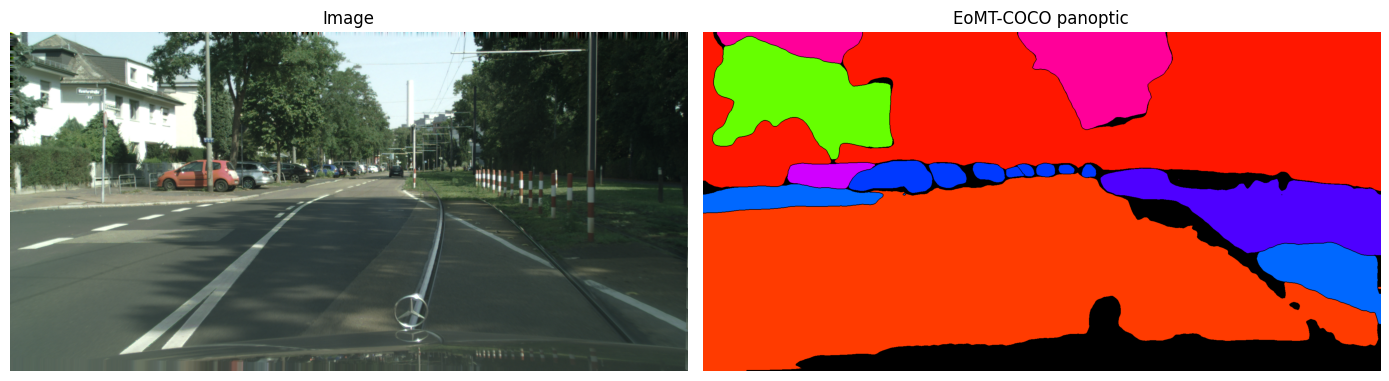

In [25]:
sem, inst = infer_panoptic(coco_model, img)
print(f"unique semantic classes in panoptic prediction: {np.unique(sem).tolist()}")

h, w = sem.shape
sem_ids = np.unique(sem)
rng = np.random.default_rng(0)
color_for = {
    int(s): np.array([0, 0, 0], dtype=np.uint8) if s == -1 or s == coco_meta.num_classes
    else (np.array(plt.cm.hsv(rng.random())[:3]) * 255).astype(np.uint8)
    for s in sem_ids
}
out = np.zeros((h, w, 3), dtype=np.uint8)
for s in sem_ids: out[sem == s] = color_for[int(s)]
combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
border = np.zeros((h, w), dtype=bool)
border[1:, :]  |= combined[1:, :]  != combined[:-1, :]
border[:-1, :] |= combined[1:, :]  != combined[:-1, :]
border[:, 1:]  |= combined[:, 1:]  != combined[:, :-1]
border[:, :-1] |= combined[:, 1:]  != combined[:, :-1]
out[border] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img.permute(1, 2, 0).cpu().numpy()); axes[0].set_title("Image")
axes[1].imshow(out);                                axes[1].set_title("EoMT-COCO panoptic")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 10. COCO to Cityscapes: remapping for comparison

To compare the two networks on the same metric, a mapping from COCO continuous id to Cityscapes train_id is needed. Unmappable COCO classes (e.g., `pole`, `rider`) end up as `255` (ignore): in the mIoU, those pixels will not be counted. "Strict" approach: no free credit for what we cannot translate.

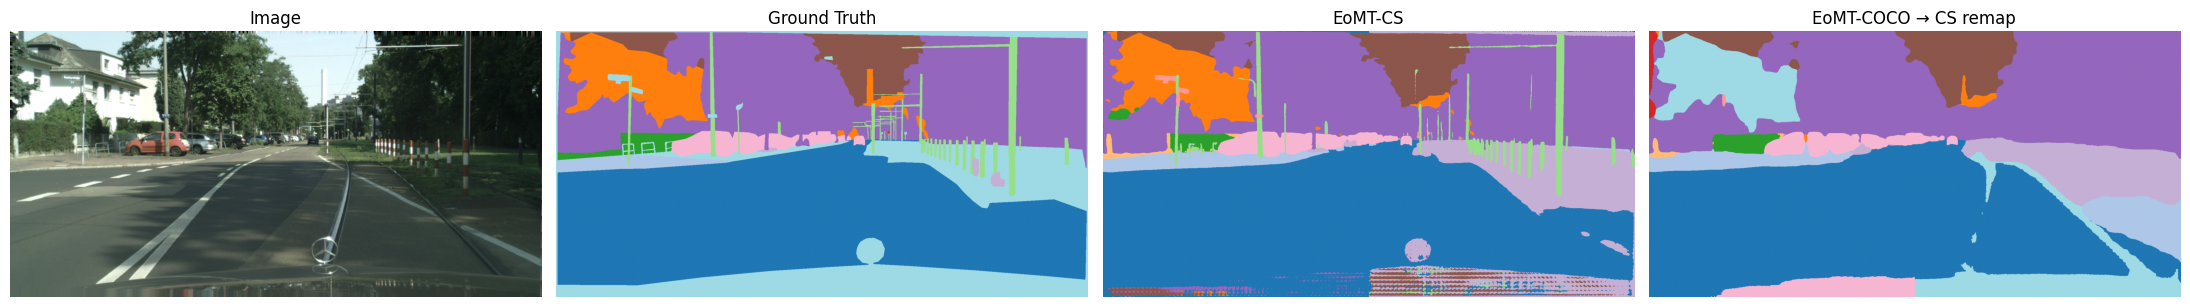

In [26]:
COCO_TO_CS = {
    # things (continuous COCO id -> CS train_id)
    0: 11,    # person
    1: 18,    # bicycle
    2: 13,    # car
    3: 17,    # motorcycle
    5: 15,    # bus
    6: 16,    # train
    7: 14,    # truck
    9: 6,     # traffic light
    11: 7,    # stop sign       -> traffic sign (loose)
    # stuff
    100: 0,   # road
    109: 3, 110: 3, 111: 3, 112: 3,  # wall-{brick,stone,tile,wood} -> wall
    116: 8,   # tree-merged     -> vegetation
    117: 4,   # fence-merged    -> fence
    119: 10,  # sky-other-merged
    123: 1,   # pavement-merged -> sidewalk
    124: 9, 125: 9, 126: 9,  # mountain/grass/dirt -> terrain (loose)
    129: 2,   # building-other-merged -> building
    131: 3,   # wall-other-merged     -> wall
}

def coco_to_cs_lut(num_coco_classes, device):
    lut = torch.full((num_coco_classes,), 255, dtype=torch.long, device=device)
    for c, t in COCO_TO_CS.items():
        if c < num_coco_classes:
            lut[c] = t
    return lut

logits_coco = infer_semantic_logits(coco_model, img)   # [133, H, W]
coco_argmax = logits_coco.argmax(0)
lut = coco_to_cs_lut(coco_meta.num_classes, device)
pred_coco_remap = lut[coco_argmax].cpu().numpy()
pred_coco_vis = np.where(pred_coco_remap == 255, 19, pred_coco_remap)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(img.permute(1,2,0).cpu().numpy());                       axes[0].set_title("Image")
axes[1].imshow(target_vis,   cmap="tab20", vmin=0, vmax=19);            axes[1].set_title("Ground Truth")
axes[2].imshow(pred_cs,      cmap="tab20", vmin=0, vmax=19);            axes[2].set_title("EoMT-CS")
axes[3].imshow(pred_coco_vis,cmap="tab20", vmin=0, vmax=19);            axes[3].set_title("EoMT-COCO → CS remap")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 11. Quantitative: mIoU on Cityscapes val

Full loop on val (500 images). For a quick sanity check put `MAX_IMAGES=50`; for the official number set it to `-1`.

In [27]:
from torchmetrics.classification import MulticlassJaccardIndex

NUM_CS = 19
IGNORE = 255
CS_NAMES = ["road","sidewalk","building","wall","fence","pole","traffic light",
            "traffic sign","vegetation","terrain","sky","person","rider","car",
            "truck","bus","train","motorcycle","bicycle"]

def per_pixel_target(target_dict, ignore=IGNORE):
    masks, labels = target_dict["masks"], target_dict["labels"]
    out = torch.full(masks.shape[-2:], ignore, dtype=torch.long, device=masks.device)
    for i, m in enumerate(masks):
        out[m] = labels[i].long()
    return out


def evaluate_semantic(model, dataset, lut=None, max_images=-1):
    """IoU per-classe su `dataset`. Se `lut` è dato, le predizioni vengono rimappate
    (è la strategia per il modello COCO-trained)."""
    metric = MulticlassJaccardIndex(num_classes=NUM_CS, ignore_index=IGNORE,
                                    average=None).to(device)
    n = len(dataset) if max_images <= 0 else min(max_images, len(dataset))
    for i in range(n):
        img_i, tgt_i = dataset[i]
        target = per_pixel_target(tgt_i).to(device)
        logits = infer_semantic_logits(model, img_i)
        pred = logits.argmax(0)
        if lut is not None:
            pred_cs = lut[pred]
            unmapped = pred_cs.eq(IGNORE)
            target = torch.where(unmapped, torch.full_like(target, IGNORE), target)
            pred = torch.where(unmapped, torch.zeros_like(pred_cs), pred_cs)
        metric.update(pred[None], target[None])
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n}")
    return metric.compute().cpu()


def print_iou(name, iou):
    print(f"\n=== {name} ===")
    for c, v in zip(CS_NAMES, iou.tolist()):
        print(f"  {c:<16} {v*100:6.2f}")
    valid = iou[~torch.isnan(iou)]
    print(f"  {'mIoU':<16} {valid.mean().item()*100:6.2f}")

In [28]:
MAX_IMAGES = -1   # -1 for all 500 val images

print(f"--- EoMT-CS on Cityscapes val (max_images={MAX_IMAGES}) ---")
iou_cs = evaluate_semantic(cs_model, val_dataset, max_images=MAX_IMAGES)
print_iou("EoMT-CS", iou_cs)

--- EoMT-CS on Cityscapes val (max_images=-1) ---
  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500
  400/500
  450/500
  500/500

=== EoMT-CS ===
  road              98.40
  sidewalk          87.36
  building          94.15
  wall              66.07
  fence             65.49
  pole              71.04
  traffic light     75.00
  traffic sign      82.13
  vegetation        93.02
  terrain           66.60
  sky               95.54
  person            85.38
  rider             71.11
  car               95.54
  truck             81.79
  bus               90.32
  train             77.36
  motorcycle        74.35
  bicycle           81.27
  mIoU              81.68


In [29]:
print(f"--- EoMT-COCO (remapped) on Cityscapes val (max_images={MAX_IMAGES}) ---")
lut = coco_to_cs_lut(coco_meta.num_classes, device)
iou_coco = evaluate_semantic(coco_model, val_dataset, lut=lut, max_images=MAX_IMAGES)
print_iou("EoMT-COCO (remapped)", iou_coco)

--- EoMT-COCO (remapped) on Cityscapes val (max_images=-1) ---
  50/500
  100/500
  150/500
  200/500
  250/500
  300/500
  350/500
  400/500
  450/500
  500/500

=== EoMT-COCO (remapped) ===
  road              94.13
  sidewalk          64.80
  building          86.76
  wall              46.20
  fence             50.00
  pole               0.00
  traffic light     60.78
  traffic sign       4.74
  vegetation        88.15
  terrain           56.59
  sky               89.73
  person            70.50
  rider              0.00
  car               84.34
  truck             29.37
  bus               71.17
  train             13.63
  motorcycle        63.78
  bicycle           73.34
  mIoU              55.16


## 12. Final comparison

The EoMT-CS should clearly win: it was trained on the same 19 classes and performs argmax directly in that space. The COCO-trained model loses on classes without a COCO analog (pole, rider, traffic sign) and on classes where the remapping is approximate (terrain mapped from grass/dirt/mountain).

In [30]:
print(f"{'class':<16} {'EoMT-CS':>9} {'EoMT-COCO':>11}")
print("-" * 40)
for c, a, b in zip(CS_NAMES, iou_cs.tolist(), iou_coco.tolist()):
    print(f"{c:<16} {a*100:>8.2f}  {b*100:>10.2f}")
print("-" * 40)
print(f"{'mIoU':<16} {iou_cs[~torch.isnan(iou_cs)].mean().item()*100:>8.2f}  "
      f"{iou_coco[~torch.isnan(iou_coco)].mean().item()*100:>10.2f}")

class              EoMT-CS   EoMT-COCO
----------------------------------------
road                98.40       94.13
sidewalk            87.36       64.80
building            94.15       86.76
wall                66.07       46.20
fence               65.49       50.00
pole                71.04        0.00
traffic light       75.00       60.78
traffic sign        82.13        4.74
vegetation          93.02       88.15
terrain             66.60       56.59
sky                 95.54       89.73
person              85.38       70.50
rider               71.11        0.00
car                 95.54       84.34
truck               81.79       29.37
bus                 90.32       71.17
train               77.36       13.63
motorcycle          74.35       63.78
bicycle             81.27       73.34
----------------------------------------
mIoU                81.68       55.16
